<a href="https://colab.research.google.com/github/uniqpy/l5-innovations-ar-coursework/blob/main/Predictive_Fault_Risk_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET PREVIEW
   record_id fault_id  fault_type  severity           location    asset_type  \
0          1     F001  Signalling  Critical   Service Corridor     Escalator   
1          2     F002  Structural       Low         Platform 2     CCTV Unit   
2          3     F003     Network       Low         Platform 1   Rail Signal   
3          4     F004  Electrical  Critical           Tunnel A  Track Sensor   
4          5     F005  Electrical      High  Station Concourse     CCTV Unit   

  detected_by        timestamp         status  resolution_time_min  ...  \
0       ENG05   4/12/2026 5:15       Resolved                  110  ...   
1       ENG21   4/13/2026 3:59  Investigating                   23  ...   
2       ENG21   5/4/2026 14:33       Resolved                   14  ...   
3       ENG44   4/1/2026 17:03           Open                  219  ...   
4       ENG12  4/16/2026 11:18       Resolved                   60  ...   

  api_response_ms  server_uptime_pct  failed_request

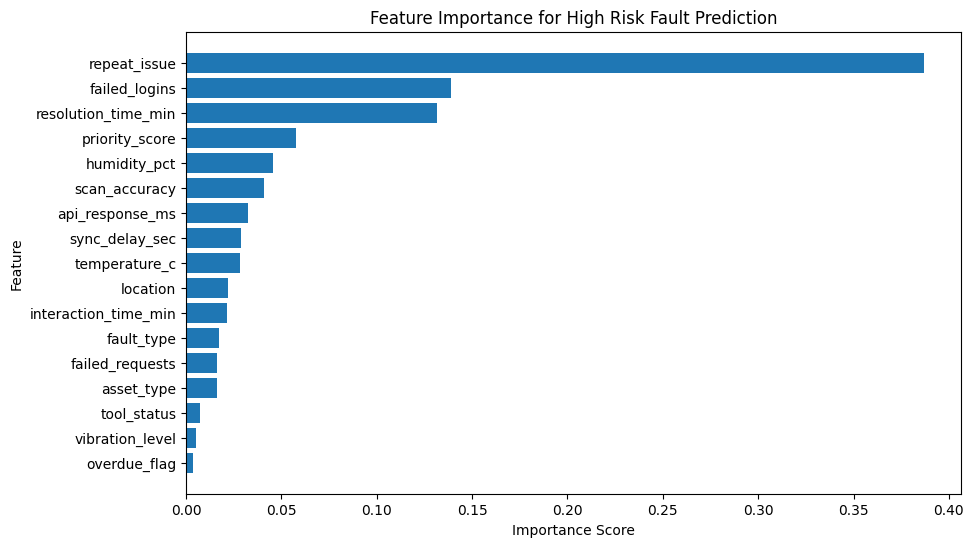


EXAMPLE PREDICTIONS
    Actual  Predicted
0        1          1
1        0          0
2        1          1
3        1          1
4        0          0
5        1          1
6        0          0
7        0          0
8        0          0
9        0          0
10       0          0
11       0          0
12       0          0
13       0          0
14       1          1

MODEL TRAINING COMPLETE
The machine learning model can now
predict whether a maintenance fault
is likely to become a high-risk issue.

This supports:
- proactive maintenance
- improved operational safety
- predictive analytics
- suspicious fault monitoring
- maintenance decision making


In [10]:

# AR Maintenance System - Predictive Fault Detection Model

# This machine learning model predicts whether
# a maintenance fault should be classified as:
# 1 = High Risk Fault
# 0 = Normal Fault The model uses operational, environmental, and behavioural maintenance data collected from the AR maintenance system.

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

import matplotlib.pyplot as plt




df = pd.read_csv("ar_maintenance_synthetic_dataset_300(in).csv")



print("===================================")
print("DATASET PREVIEW")
print("===================================")

print(df.head())


print("\n===================================")
print("DATASET SIZE")
print("===================================")

print(df.shape)


print("\n===================================")
print("COLUMN NAMES")
print("===================================")

print(df.columns)


# =========================================================
# CREATE TARGET VARIABLE
# =========================================================

# This creates the prediction label.
#
# High risk faults are identified using:
# - critical severity
# - high priority score
# - suspicious activity
# - repeat issues


def classify_risk(row):

    if (
        row['severity'] == 'Critical'
        or row['priority_score'] >= 8
        or row['suspicious_flag'] == True
        or row['repeat_issue'] == True
    ):

        return 1

    else:

        return 0


df['high_risk_fault'] = df.apply(classify_risk, axis=1)


# VIEW TARGET DISTRIBUTION

print("\n===================================")
print("HIGH RISK FAULT DISTRIBUTION")
print("===================================")

print(df['high_risk_fault'].value_counts())



# SELECT FEATURES


# These are the variables the model will use to make predictions.

features = [

    'fault_type',
    'location',
    'asset_type',
    'resolution_time_min',
    'repeat_issue',
    'priority_score',
    'tool_status',
    'overdue_flag',
    'failed_logins',
    'interaction_time_min',
    'scan_accuracy',
    'api_response_ms',
    'failed_requests',
    'sync_delay_sec',
    'temperature_c',
    'humidity_pct',
    'vibration_level'

]

X = df[features].copy()

# Prediction target

y = df['high_risk_fault']



# ENCODE CATEGORICAL DATA


# Machine learning algorithms cannot
# process text values directly.
# This converts text categories into numbers.

label_encoders = {}

for column in X.columns:

    if X[column].dtype == 'object':

        encoder = LabelEncoder()

        X[column] = encoder.fit_transform(X[column])

        label_encoders[column] = encoder



# SPLIT TRAINING AND TESTING DATA


# 80% Training Data
# 20% Testing Data

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,
    random_state=42)



# CREATE MACHINE LEARNING MODEL


# Random Forest was selected because:
# - good performance with structured data
# - reduces overfitting
# - easy to explain
# - handles multiple variables well

model = RandomForestClassifier(n_estimators=100, random_state=42)

# TRAIN THE MODEL

model.fit(X_train, y_train)



# GENERATE PREDICTIONS


predictions = model.predict(X_test)



# EVALUATE MODEL PERFORMANCE

accuracy = accuracy_score(y_test, predictions)

print("\n===================================")
print("MODEL ACCURACY")
print("===================================")

print(f"Accuracy Score: {accuracy:.2f}")



# CLASSIFICATION REPORT


print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================")

print(classification_report(y_test, predictions))



# CONFUSION MATRIX


print("\n===================================")
print("CONFUSION MATRIX")
print("===================================")

cm = confusion_matrix(y_test, predictions)

print(cm)



# FEATURE IMPORTANCE ANALYSIS

# This shows which variables had the strongest impact on predictions.

importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})


importance_df = importance_df.sort_values( by='Importance', ascending=False)


print("\n===================================")
print("FEATURE IMPORTANCE")
print("===================================")

print(importance_df)


# VISUALISE FEATURE IMPORTANCE


plt.figure(figsize=(10, 6))

plt.barh(

    importance_df['Feature'],
    importance_df['Importance']

)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance for High Risk Fault Prediction")

plt.gca().invert_yaxis()

plt.show()

# SHOW SAMPLE PREDICTIONS


print("\n===================================")
print("EXAMPLE PREDICTIONS")
print("===================================")

example_results = pd.DataFrame({

    'Actual': y_test.values,
    'Predicted': predictions })

print(example_results.head(15))


print("\n===================================")
print("MODEL TRAINING COMPLETE")
print("===================================")

print("The machine learning model can now")
print("predict whether a maintenance fault")
print("is likely to become a high-risk issue.")

print("\nThis supports:")
print("- proactive maintenance")
print("- improved operational safety")
print("- predictive analytics")
print("- suspicious fault monitoring")
print("- maintenance decision making")